First 5 rows:
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 column

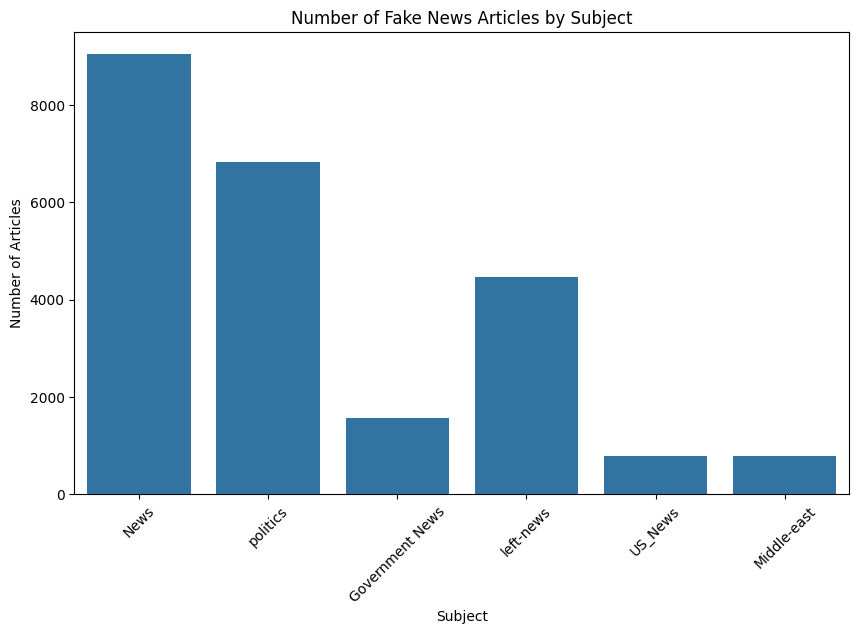

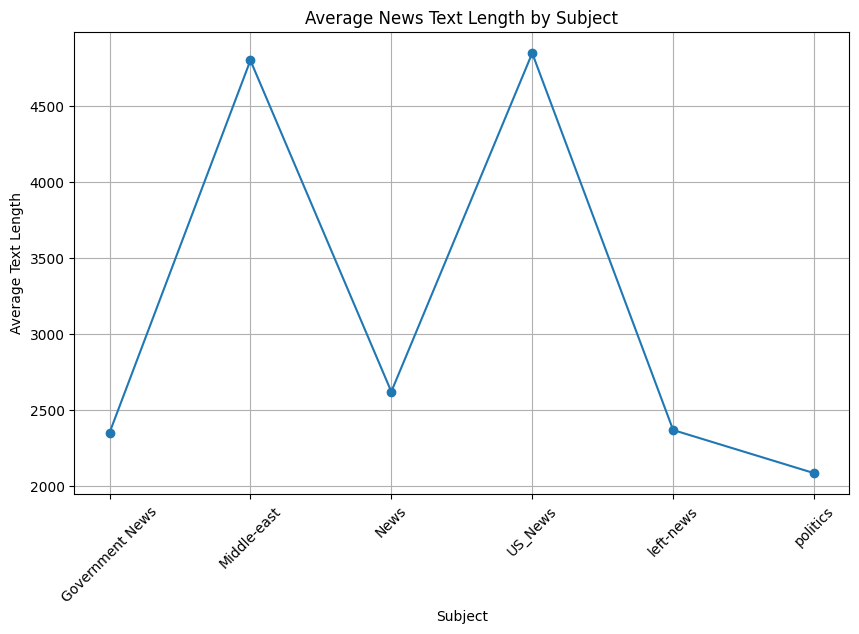

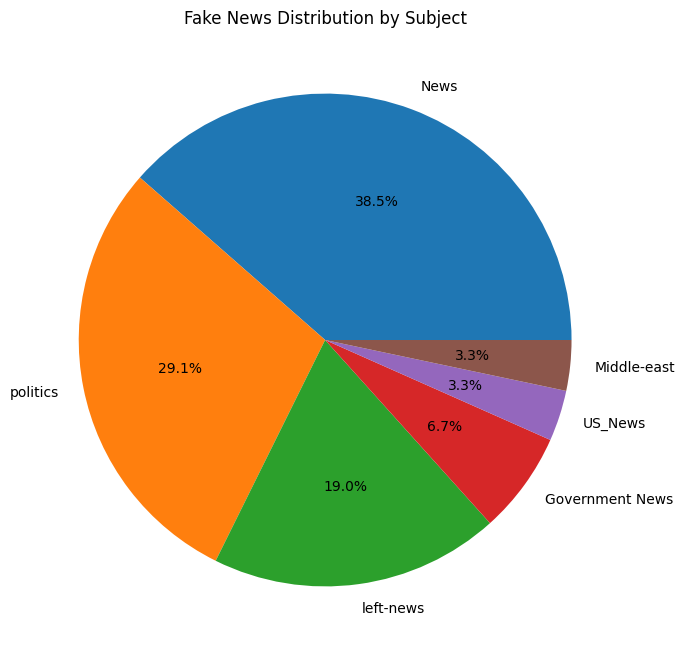


========== SUMMARY ==========
Total Number of Articles: 23481

Number of Articles by Subject:
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

Average Text Length:
subject
Government News    2352.573885
Middle-east        4799.847044
News               2622.963646
US_News            4847.337165
left-news          2370.988562
politics           2087.715977
Name: Text Length, dtype: float64


In [10]:
# ============================================
# FAKE NEWS DETECTION USING PYTHON
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# 1. Load Dataset
# --------------------------------------------

df = pd.read_csv("/content/Fake.csv.zip")

# --------------------------------------------
# 2. Inspect Dataset
# --------------------------------------------

print("First 5 rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nColumn Names:")
print(df.columns.tolist())

# --------------------------------------------
# 3. Create Calculated Field
# --------------------------------------------

# Create Text Length from the news article
df["Text Length"] = df["text"].astype(str).apply(len)

print("\nCalculated Field:")
print(df[["text", "Text Length"]].head())

# --------------------------------------------
# 4. Bar Chart - News by Subject
# --------------------------------------------

plt.figure(figsize=(10, 6))

sns.countplot(
    x="subject",
    data=df
)

plt.title("Number of Fake News Articles by Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)

plt.show()

# --------------------------------------------
# 5. Line Chart - Average Text Length
# --------------------------------------------

average_length = df.groupby("subject")["Text Length"].mean()

plt.figure(figsize=(10, 6))

plt.plot(
    average_length.index,
    average_length.values,
    marker="o"
)

plt.title("Average News Text Length by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Text Length")
plt.xticks(rotation=45)
plt.grid()

plt.show()

# --------------------------------------------
# 6. Pie Chart - News by Subject
# --------------------------------------------

subject_count = df["subject"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    subject_count.values,
    labels=subject_count.index,
    autopct="%1.1f%%"
)

plt.title("Fake News Distribution by Subject")

plt.show()

# --------------------------------------------
# 7. Display Summary
# --------------------------------------------

print("\n========== SUMMARY ==========")

print("Total Number of Articles:", len(df))

print("\nNumber of Articles by Subject:")
print(df["subject"].value_counts())

print("\nAverage Text Length:")
print(df.groupby("subject")["Text Length"].mean())